# **Recovering injected behavioural biases from a synthetic trading record**
## **P01 — Behavioural Finance**

---

**Authors:** Alan Jesús Hernández Soto · Francisco Uriel Ledezma Chávez · Esteban Vega Campos · *(fourth member)*
**Programme:** Ingeniería Financiera
**Institution:** ITESO, Universidad Jesuita de Guadalajara
**Course:** Comportamiento en las Finanzas y Toma de Decisiones
**Date:** September 2026

---

We build a simulator that generates synthetic brokerage records, inject a disposition
mechanism and an overprecision mechanism at magnitudes fixed in advance, and then try to
recover those magnitudes with the estimators used on real data. The value of the exercise
is entirely in the failures: a positive finding on real data can never be separated from a
coding error, because there is no ground truth to check it against. Here there is one, and
three of the eight scenarios below return a confident answer that is wrong.

## Contents

1. [Pre-analysis statement](#s1)
2. [Simulator design](#s2)
   - [2.1 The security universe](#s21)
   - [2.2 Traders and the injected mechanism](#s22)
   - [2.3 Trading costs, and what "gross" means here](#s23)
   - [2.4 Estimator conventions](#s24)
3. [Results across the eight scenarios](#s3)
4. [Validation](#s4)
5. [The scenarios where something happened](#s5)
6. [Diagnosing the turnover slope on gross returns](#s6)
7. [Independence of the injected parameters](#s7)
8. [Standard errors and clustering](#s8)
9. [What the estimators cannot distinguish](#s9)
10. [Conclusions](#s10)
11. [References](#s11)
12. [Reproducibility](#s12)

---

<a id="s1"></a>

## 1. Pre-analysis statement

*Written and committed before any estimator was run against simulated output. The
version-controlled copy is `PRE_ANALYSIS.md`.*

We inject two parameters. The disposition strength $\delta_i$ enters as a multiplier on a
daily sell hazard, so that a position trading above its purchase price has its immediate
probability of sale scaled by $(1+\delta_i)$ and one below its purchase price by
$(1-\delta_i)$. The overprecision parameter $\kappa_i$ enters the same hazard as a level
shift, $h_0(1+4\kappa_i)$, so it governs how often an account acts at all without touching
which domain it closes. Neither PGR, PLR nor turnover is parametrised anywhere in the code;
all three are emergent. Per scenario, the tabulated $\delta$ and $\kappa$ are the means of
independent Beta draws across the population, degenerate at zero where the scenario
specifies zero.

We expect the following. In scenario 1 both estimators should be quiet. In scenarios 2 and 3
we expect $\widehat{PGR}-\widehat{PLR}$ to be positive and larger in 3 than in 2, monotone in
the injected $\delta$ but not equal to it, since the hazard multiplier and the realised ratio
are different quantities. In scenarios 4 and 5 we expect the disposition estimator to stay
quiet while the turnover slope on net returns turns negative and more negative as $\kappa$
rises, with the gross slope close to zero. Scenario 6 should show both, and we expect the
measured disposition ratio to be **attenuated** relative to scenario 3 because higher churn
shortens holding periods and moves positions closer to their purchase price. Scenarios 7 and
8 carry $\delta=0$ and we nonetheless expect a positive, significant $\widehat{PGR}-\widehat{PLR}$
in both. On the overconfidence side we expect the Barber–Odean contrast only where $\kappa$
carries the variation, and wherever the selling rule conditions on the purchase price
(scenarios 2, 3, 6) or trims winners (scenario 7) we expect reverse causality to push the
**gross** slope positive. Cash drag is eliminated by construction through same-day
redeployment and the bid–ask spread is excluded from the gross measure by definition, so
neither should appear unless deliberately switched on. Finally we expect
$\mathrm{corr}(\delta_i,\kappa_i)$ to be within Monte Carlo noise of zero, and
$\mathrm{corr}(\delta_i,\text{turnover}_i)$ to be materially negative.

Two of these predictions turn out to be wrong, and they are flagged where they fail.

---

In [1]:
import os, sys, pathlib, warnings

# Work from the repository root whether the notebook is launched from here or
# from notebooks/, so that `src/` and `results/` resolve the same way either way.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "src" / "bfsim").is_dir())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace

from bfsim.config import (MASTER_SEED, PriceConfig, PopulationConfig, CostConfig,
                          EngineConfig, ScenarioConfig, stream_rngs)
from bfsim.agents import draw_population
from bfsim.prices import simulate_universe
from bfsim.engine import run_scenario
from bfsim.estimators import pgr_plr, bootstrap_accounts, turnover_regression, CONTROLS
from bfsim import figures as fx
from bfsim.scenarios import (SCENARIOS, common_universe, analyse, run_all, results_table,
                             independence_table, convention_table, placebo_table,
                             discrimination_table, replicate_seeds)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")
FIG = "results/figures"

---

<a id="s2"></a>

## 2. Simulator design

<a id="s21"></a>

### 2.1 The security universe

Sixty securities are simulated over 750 trading days from a three-factor structure, in which
the daily log return of security $j$ is

$$r_{j,t} \;=\; a_j \;+\; \beta^{M}_j f^{M}_t \;+\; \beta^{V}_j f^{V}_t \;+\; \beta^{S}_j f^{S}_t \;+\; \varepsilon_{j,t},$$

with one market factor carrying an annualised volatility of 16 % and two orthogonal style
factors at 10 %, market betas drawn as $N(1,\,0.35)$ and clipped to $[0.2,\,2.0]$, style betas
drawn as $N(0,\,0.5)$, and idiosyncratic volatility drawn uniformly between 20 % and 45 % a
year. A factor structure rather than sixty independent geometric Brownian motions matters for
two reasons: it produces the pairwise return correlation of roughly 0.18 that any real
cross-section displays, and it gives the overconfidence regression a risk control with actual
content, since portfolio beta then varies across accounts for reasons unrelated to how often
the account trades.

The intercept deserves a word, because we changed it during construction. Under a CAPM-like
drift, $a_j = \mu_j - \tfrac12\sigma_j^2$ with $\mu_j = r_f + \beta_j^M\,\text{ERP}$, the
expected **log** return varies across securities with a standard deviation of about three
percentage points a year and correlates $-0.90$ with idiosyncratic volatility. Any rule that
selects on past returns then acquires a drift differential it had no information about, which
is observationally identical to leakage. We therefore impose a common expected log return of
6 % a year on every security. Expected *arithmetic* returns still differ by half the variance,
but that is a Jensen artefact and cannot make a portfolio compound faster.

**The big constraint holds by construction.** The entire price panel is drawn from its own
generator before a single agent exists, and the engine only ever reads from it; there is no
code path by which a trading decision can reach the return that follows it. Section 4 tests
the claim empirically anyway.

securities 60   trading days 750
annualised volatility   mean 0.379   range [0.218, 0.501]
mean pairwise return correlation   0.1940
market beta   mean 1.061   sd 0.381
expected log drift, imposed on every security   0.060 per year


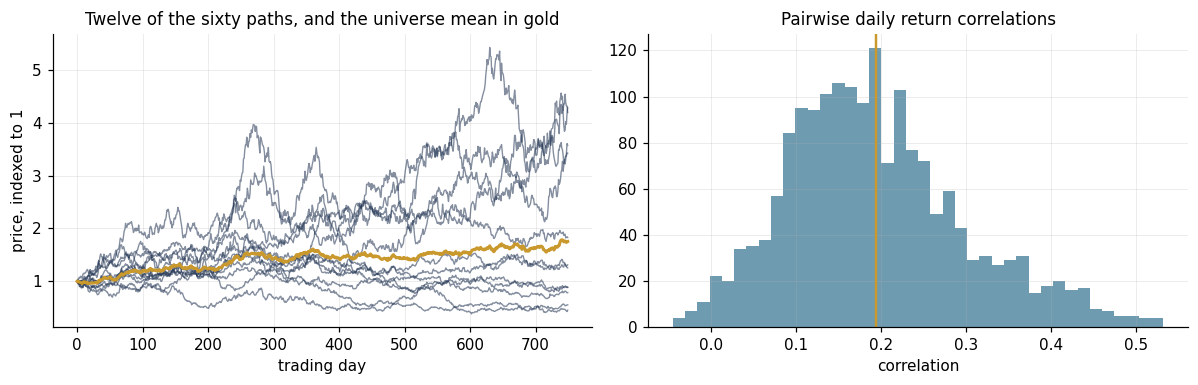

In [2]:
price_cfg = PriceConfig()
universe = common_universe(price_cfg)

r = np.diff(np.log(universe.prices), axis=0)
corr = np.corrcoef(r.T)
iu = np.triu_indices_from(corr, 1)
print(f"securities {universe.n_securities}   trading days {universe.n_days}")
print(f"annualised volatility   mean {r.std(0).mean()*np.sqrt(252):.3f}   "
      f"range [{r.std(0).min()*np.sqrt(252):.3f}, {r.std(0).max()*np.sqrt(252):.3f}]")
print(f"mean pairwise return correlation   {corr[iu].mean():.4f}")
print(f"market beta   mean {universe.beta_market.mean():.3f}   "
      f"sd {universe.beta_market.std():.3f}")
print(f"expected log drift, imposed on every security   "
      f"{price_cfg.common_log_drift_annual:.3f} per year")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sub = np.linspace(0, universe.n_securities - 1, 12).astype(int)
for j in sub:
    ax[0].plot(universe.prices[:, j] / universe.prices[0, j], lw=0.9,
               color=fx.ANCHOR, alpha=0.55)
ax[0].plot((universe.prices / universe.prices[0]).mean(axis=1), lw=2.0, color=fx.GOLD)
ax[0].set_title("Twelve of the sixty paths, and the universe mean in gold")
ax[0].set_xlabel("trading day"); ax[0].set_ylabel("price, indexed to 1")
ax[1].hist(corr[iu], bins=40, color=fx.ACCENT)
ax[1].axvline(corr[iu].mean(), color=fx.GOLD, lw=1.6)
ax[1].set_title("Pairwise daily return correlations")
ax[1].set_xlabel("correlation")
plt.tight_layout(); plt.savefig(f"{FIG}/universe.png", dpi=160, bbox_inches="tight"); plt.show()

<a id="s22"></a>

### 2.2 Traders and the injected mechanism

Each scenario regenerates a population of $N=1000$ accounts. Every account receives a
disposition strength $\delta_i$, an overprecision intensity $\kappa_i$, starting capital
$W_i$ drawn log-uniformly between \$10,000 and \$500,000, and a target number of positions
$n_i$ drawn uniformly on $\{5,\dots,30\}$. The log-uniform capital draw is deliberate, since a
uniform draw would put half the population above \$255,000 and no brokerage cross-section
looks like that.

We read the scenario table's $\delta$ and $\kappa$ as **population means rather than
constants**, drawing each from a Beta distribution with that mean and a concentration of six.
Without cross-sectional dispersion the independence diagnostics of section 7 would have
nothing to correlate — one cannot report $\mathrm{corr}(\delta_i,\kappa_i)$ over a constant —
and the turnover regression would lose most of its identification. The two are drawn from
separate generator streams spawned off a single master seed, so independence is a property of
the construction and not of an inspection after the fact.

The injected mechanism is a daily hazard of closing each held position,

$$h_{i,j,t} \;=\; \underbrace{h_0\,\bigl(1 + 4\kappa_i\bigr)}_{\text{how often the account acts}} \;\times\; \underbrace{\begin{cases} 1+\delta_i & P_t > \text{basis} \\ 1 & P_t = \text{basis} \\ 1-\delta_i & P_t < \text{basis}\end{cases}}_{\text{which domain it closes}}$$

with $h_0 = 0.004$, which corresponds to an unbiased account turning its portfolio over
roughly once a year. Nothing in this expression is PGR. The quantity the estimator reports
sits one level above the quantity we inject, and the gap between them is the entire point:
$\widehat{PGR}$ is a consequence of the hazard, the holding-period distribution the hazard
induces, and the price path the positions happen to follow. Proceeds are redeployed the same
day into a security chosen uniformly at random, independently of its past and its future.

delta   mean 0.796  sd 0.152
kappa   mean 0.303  sd 0.174
realised corr(delta, kappa) = -0.0060  (null s.e. 0.0158)
capital  median $68,090   positions  mean 17.6


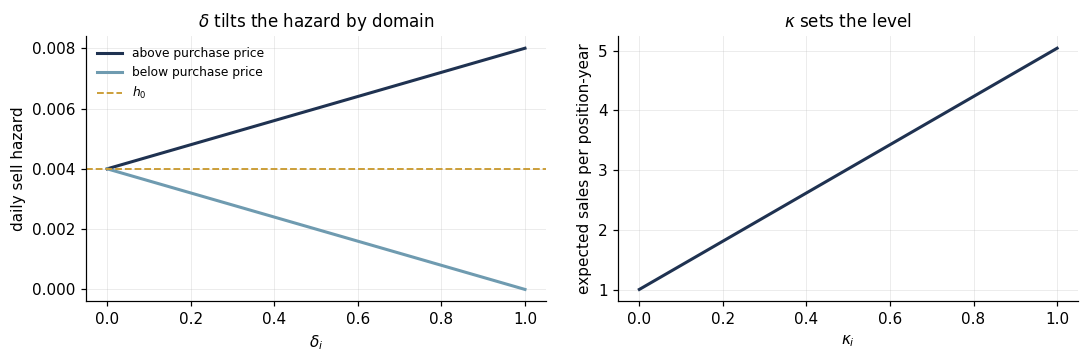

In [3]:
demo = draw_population(PopulationConfig(n_traders=4000, delta_mean=0.8, kappa_mean=0.3),
                       stream_rngs(99))
print(f"delta   mean {demo.delta.mean():.3f}  sd {demo.delta.std():.3f}")
print(f"kappa   mean {demo.kappa.mean():.3f}  sd {demo.kappa.std():.3f}")
print(f"realised corr(delta, kappa) = {np.corrcoef(demo.delta, demo.kappa)[0,1]:+.4f}  "
      f"(null s.e. {1/np.sqrt(demo.n_traders-3):.4f})")
print(f"capital  median ${np.median(demo.wealth):,.0f}   positions  mean {demo.n_pos.mean():.1f}")

eng = EngineConfig()
d = np.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(d, eng.base_hazard*(1+d), color=fx.ANCHOR, lw=2, label="above purchase price")
ax[0].plot(d, eng.base_hazard*(1-d), color=fx.ACCENT, lw=2, label="below purchase price")
ax[0].axhline(eng.base_hazard, color=fx.GOLD, ls="--", lw=1.2, label=r"$h_0$")
ax[0].set_xlabel(r"$\delta_i$"); ax[0].set_ylabel("daily sell hazard")
ax[0].set_title(r"$\delta$ tilts the hazard by domain"); ax[0].legend(frameon=False, fontsize=8)
k = np.linspace(0, 1, 100)
ax[1].plot(k, eng.base_hazard*(1+eng.kappa_multiplier*k)*252, color=fx.ANCHOR, lw=2)
ax[1].set_xlabel(r"$\kappa_i$"); ax[1].set_ylabel("expected sales per position-year")
ax[1].set_title(r"$\kappa$ sets the level")
plt.tight_layout(); plt.savefig(f"{FIG}/mechanism.png", dpi=160, bbox_inches="tight"); plt.show()

<a id="s23"></a>

### 2.3 Trading costs, and what "gross" means here

Every transaction pays a commission of 10 basis points of notional with a floor of one US
dollar, and crosses a quoted spread of 30 basis points, so fills occur at the mid plus or
minus 15 basis points. A full round trip of the portfolio therefore costs
$2\times(10+15)=50$ basis points, which is the number to hold on to when reading the
overconfidence slope in section 3.

The gross and net measures are deliberately defined so that one of the four diagnoses the
assignment warns about cannot occur. Each account runs a shadow portfolio that takes exactly
the same decisions — same securities, same fractions sold, same days — but fills at the mid
and pays no commission. **Gross return is that shadow portfolio's return; net return is the
real one.** Gross is therefore not "the return before we subtracted costs at the end", which
would still have the spread baked into the price path; it is the counterfactual return of
identical behaviour in a frictionless market. Whenever the two diverge, the divergence is
costs and nothing else.

<a id="s24"></a>

### 2.4 Estimator conventions

The disposition estimator accumulates four counts. On every day an account sells something,
each position it holds that day is classified against its purchase price, and

$$\widehat{PGR} = \frac{G_r}{G_r+G_p}, \qquad \widehat{PLR} = \frac{L_r}{L_r+L_p}.$$

Four conventions decide what those counts mean, and each of them changes the answer:

**Silent days.** Days on which the account sold nothing contribute nothing to any count. This
is not innocuous. The same simulation counted on every day rather than on sale days gives a
difference of 0.0064 in scenario 3 instead of 0.0749, because the conditioning inflates both
realisation rates by roughly the reciprocal of the frequency of sale days. The *ratio* is far
more stable than the difference under this convention, which is the first reason to report
both.

**Partial sales.** A sale is counted at position level, so trimming a quarter of a lot is one
realisation and the surviving stub is classified again the following day. The share-weighted
alternative, in which a quarter-sale contributes 0.25 to $G_r$ and 0.75 to $G_p$, is computed
in parallel. The two agree exactly in every scenario where positions are closed whole, and
differ by a factor of 4.4 in the one scenario that trims — which is section 5's main
diagnostic.

**Cost basis.** The default is per-lot: each purchase creates a lot and a full sale destroys
it. Average cost across all lots of the same security within an account is accumulated on the
same pass, and attenuates the estimate by about 8 % wherever the effect is large, because
blending a new purchase into an old lot pulls the reference point toward the current price and
reclassifies some extreme positions.

**Positions exactly at the purchase price.** They enter no count. With continuous prices this
is a measure-zero event and the realised number of such observations is zero in all eight
scenarios, which the results table reports so that the reader need not take it on faith.

Standard errors come from a bootstrap that resamples **accounts**, not transactions. The naive
position-day bootstrap is computed alongside purely to show how badly it misleads.

---

<a id="s3"></a>

## 3. Results across the eight scenarios

Each scenario regenerates the full population under its stated configuration. All eight share
one price panel, because null recovery and monotonicity are comparisons *across* scenarios and
redrawing the market for each would mix a behavioural difference with a different realised
market; section 4 checks separately that the conclusions survive redrawing it.

In [4]:
%%time
outputs = run_all(universe, n_boot=2000, verbose=False)
table = results_table(outputs)
table.to_csv("results/scenarios.csv")

disp_cols = ["Scenario", "delta_inj", "kappa_inj", "PGR", "se_PGR", "PLR", "se_PLR",
             "PGR-PLR", "se_diff", "t_diff", "PGR/PLR", "se_ratio", "Turnover"]
table[disp_cols]

CPU times: total: 19.9 s
Wall time: 19.9 s


,Scenario,delta_inj,kappa_inj,PGR,se_PGR,PLR,se_PLR,PGR-PLR,se_diff,t_diff,PGR/PLR,se_ratio,Turnover
#,,,,,,,,,,,,,
1,Null,0.00000,0.00000,0.05099,0.00057,0.05014,0.00058,0.00085,0.00044,1.95000,1.01694,0.00877,1.00461
2,"Disposition only, low",0.30000,0.00000,0.06245,0.00071,0.03582,0.00051,0.02663,0.00076,35.08984,1.74344,0.02755,1.07208
3,"Disposition only, high",0.80000,0.00000,0.08660,0.00093,0.01173,0.00033,0.07487,0.00102,73.35749,7.38544,0.22776,1.06837
4,"Turnover only, low",0.00000,0.30000,0.05370,0.00056,0.05360,0.00057,0.00010,0.00031,0.33379,1.00191,0.00572,2.22766
5,"Turnover only, high",0.00000,0.80000,0.05700,0.00052,0.05728,0.00053,-0.00029,0.00023,-1.24497,0.99500,0.00400,4.24579
6,Both active,0.80000,0.80000,0.11581,0.00135,0.01735,0.00037,0.09846,0.00148,66.50418,6.67371,0.17791,3.36125
7,Rebalancing confound,0.00000,0.00000,0.07355,0.00065,0.04016,0.00042,0.03338,0.00048,70.24093,1.83112,0.01415,1.19450
8,Mean-reversion confound,0.00000,0.00000,0.05754,0.00059,0.04067,0.00047,0.01686,0.00044,38.06657,1.41463,0.01255,1.04668


In [5]:
table[["Scenario", "beta_gross", "se_gross", "t_gross", "beta_net", "se_net", "t_net"]]

,Scenario,beta_gross,se_gross,t_gross,beta_net,se_net,t_net
#,,,,,,,
1,Null,0.00123,0.01557,0.07912,-0.00474,0.01549,-0.30576
2,"Disposition only, low",0.06266,0.01498,4.18385,0.05648,0.01491,3.78707
3,"Disposition only, high",0.15070,0.01340,11.24510,0.14368,0.01331,10.79433
4,"Turnover only, low",-0.00183,0.00343,-0.53299,-0.00776,0.00338,-2.29681
5,"Turnover only, high",-0.00056,0.00354,-0.15817,-0.00647,0.00348,-1.85902
6,Both active,0.02820,0.00355,7.94201,0.02180,0.00348,6.27091
7,Rebalancing confound,0.01354,0.01522,0.88948,0.00788,0.01515,0.51968
8,Mean-reversion confound,0.06403,0.01466,4.36751,0.05796,0.01459,3.97311


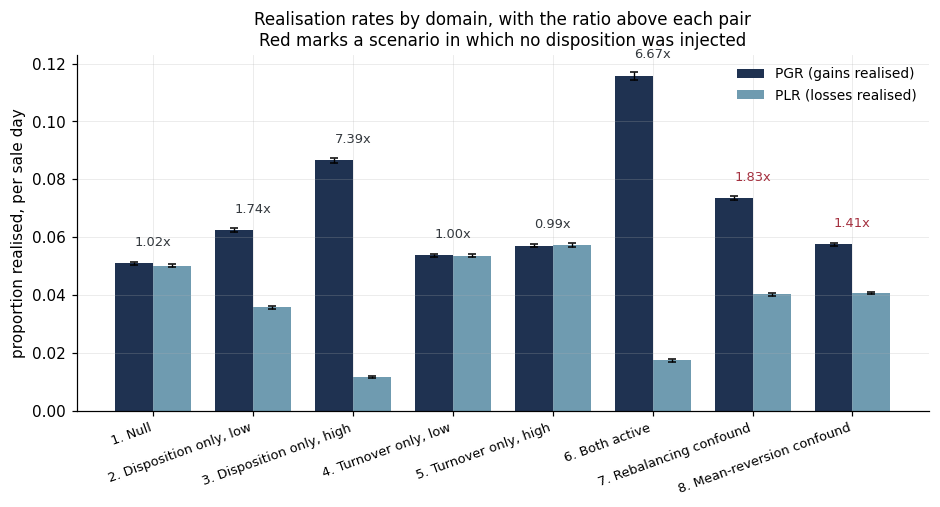

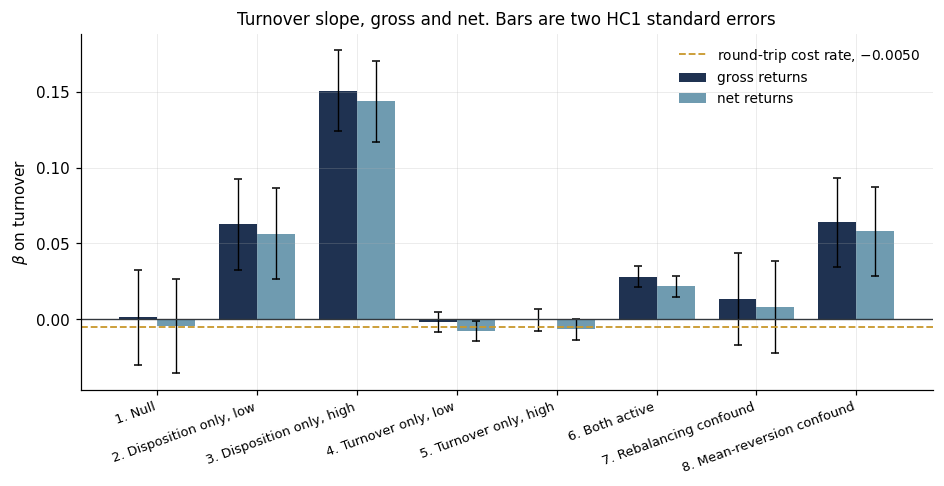

theoretical round-trip cost per unit of annual turnover: 0.00500


In [6]:
fx.pgr_plr_bars(table, f"{FIG}/pgr_plr.png"); plt.show()
cost_rate = 2 * (CostConfig().commission_bps + CostConfig().half_spread_bps) * 1e-4
fx.slopes(table, cost_rate, f"{FIG}/slopes.png"); plt.show()
print(f"theoretical round-trip cost per unit of annual turnover: {cost_rate:.5f}")

**Reading the table.** The null is quiet, the disposition estimator is monotone in the
injected $\delta$, and the two turnover-only scenarios leave it undisturbed at
$+0.0001$ and $-0.0003$. On the overconfidence side, scenarios 4 and 5 reproduce Barber and
Odean exactly: the gross slope is indistinguishable from zero at $-0.0018$ and $-0.0006$, and
the net slope is negative at $-0.0078$ and $-0.0065$. Those net slopes are worth pausing on,
because $-0.005$ is precisely the round-trip cost rate written into the cost model. The
overconfidence regression is not measuring a behavioural parameter at all; it is recovering
the commission and spread schedule, which is the strongest validation in the whole exercise
and also the sharpest statement of what the test can and cannot claim.

**The first pre-analysis prediction fails here.** We expected the net slope to become *more*
negative from scenario 4 to scenario 5 as $\kappa$ rises. It does not, and it should not have
been expected to: the slope is a cost per unit of turnover and the cost schedule is the same
in both. What rises with $\kappa$ is the *level* of the drag, from 1.34 % a year in scenario 4
to 2.53 % in scenario 5, and the dispersion of turnover across accounts. Monotonicity in
$\kappa$ lives in the drag, not in the coefficient.

The three rows that matter are 6, 7 and 8, and they are taken up in section 5.

---

<a id="s4"></a>

## 4. Validation

Four things have to hold before any of the above can be believed: the null has to come back
empty, the recovered effect has to move monotonically with the injected parameter, each
estimator has to stay quiet when only the other one's parameter is active, and no predictive
information may have leaked from the price panel into the trading decision.

In [7]:
placebo = placebo_table(outputs)
placebo.to_csv("results/placebo.csv")
placebo

,Scenario,n_trades,n_pairs,n_days,diff,t_stat,diff_log,t_log
#,,,,,,,,
1,Null,67370,29942,730,0.00023,0.65699,0.00023,0.68518
2,"Disposition only, low",69492,30387,730,0.00046,1.25727,0.00047,1.31403
3,"Disposition only, high",65460,28499,730,-0.00007,-0.47380,-0.00008,-0.50197
4,"Turnover only, low",129447,40326,730,0.00020,1.41307,0.00019,1.33340
5,"Turnover only, high",236053,43500,730,-0.00000,-0.08261,-0.00000,-0.09316
6,Both active,169512,41739,730,-0.00025,-2.19760,-0.00023,-2.12047
7,Rebalancing confound,289848,30838,730,-0.00004,0.06206,-0.00001,0.14804
8,Mean-reversion confound,68882,30246,730,-0.00046,-1.30393,-0.00051,-1.49034


**The leakage placebo, and how it lied to us first.** The test compares the forward 20-day
return of every security an agent bought against the same-day equal-weighted universe, so a
rule that systematically acquires future outperformance shows up as a non-zero difference. Run
naively it returned $t=-7.5$ in scenario 7, which would have been a violation of the big
constraint. It was not. A thousand accounts buying the same security on the same day is one
purchase decision observed a thousand times, and purchases made on the same day share a market
shock; de-duplicating $(\text{day},\text{security})$ pairs and clustering by day takes the same
statistic to $t=+0.06$. The panel itself carries no reversal — the cross-sectional correlation
between a security's past 20-day return and its next 20-day return is $+0.023$, with a
day-clustered $t$ of 0.12 on the bottom-quintile forward excess. Every scenario now sits inside
$|t|\le 2.2$, which for eight tests is what independence looks like.

The episode is worth recording rather than quietly fixing, because it is the exact failure the
assignment describes in the disposition estimator, appearing in the diagnostic instead: an
observation count inflated by repetition turns economic noise into a decisive $t$-statistic.

In [8]:
%%time
seeds = [20260913, 7, 101, 4242, 31337, 2, 13, 55]
reps = {}
for i in (0, 2, 6):
    cfg = SCENARIOS[i]
    reps[cfg.index] = replicate_seeds(cfg, seeds, n_boot=300)
    reps[cfg.index].to_csv(f"results/replication_s{cfg.index}.csv")

summary = pd.DataFrame({
    f"S{k}": r[["PGR-PLR", "se_diff", "ratio", "beta_gross"]].agg(["mean", "std", "min", "max"]).stack()
    for k, r in reps.items()})
summary

CPU times: total: 59.9 s
Wall time: 1min


S1      S3      S7
mean PGR-PLR     0.00022 0.07622 0.03202
     se_diff     0.00045 0.00104 0.00047
     ratio       1.00446 7.33842 1.80195
     beta_gross  0.00313 0.14068 0.02273
std  PGR-PLR     0.00050 0.00581 0.00271
     se_diff     0.00002 0.00014 0.00002
     ratio       0.01003 0.37522 0.06729
     beta_gross  0.01551 0.01328 0.01243
min  PGR-PLR    -0.00062 0.06892 0.02797
     se_diff     0.00043 0.00088 0.00045
     ratio       0.98778 6.74915 1.69115
     beta_gross -0.01359 0.11300 0.01264
max  PGR-PLR     0.00085 0.08399 0.03457
     se_diff     0.00049 0.00121 0.00050
     ratio       1.01694 7.72766 1.85616
     beta_gross  0.02782 0.15070 0.04496

**Null recovery.** Within the shared price panel the null returns
$\widehat{PGR}-\widehat{PLR} = 0.00085$ with an account-clustered standard error of 0.00044,
which is a $t$ of 1.95 — a marginal rejection of a hypothesis that is true by construction.
Across eight independently redrawn panels the mean is 0.00022 with a standard deviation of
0.00050, and over a longer sixteen-panel run the mean was 0.000125 with $t=1.32$ and nine of
sixteen draws positive. The null is genuinely quiet; what is not quiet is the single-panel
$t$-statistic.

That gap is the finding, and it generalises directly to real data. Every account in the sample
is exposed to the same market path, so the account bootstrap — which is already the correct
level of clustering for the dependence *within* an account — still treats a common price shock
as independent information across accounts. A disposition ratio of 1.02 measured on one
brokerage panel with a $t$ of 2 is not evidence of anything, and the only way to find that out
is to redraw the market, which is exactly what a researcher with a single real dataset cannot
do.

**Monotonicity.** The recovered difference rises from 0.00085 to 0.0266 to 0.0749 as $\delta$
goes from 0 to 0.3 to 0.8, and the ratio from 1.02 to 1.74 to 7.39, with the scenario-3 ratio
stable at $7.34\pm0.38$ across eight redrawn panels. Recovery is monotone but not
proportional, and it should not be: the injected $\delta$ is a multiplier on a hazard, while
the ratio is what that multiplier does to a proportion after a holding-period distribution and
a price path have intervened.

**Cross-estimator quiet holds in one direction only, and the failure is informative.** In the
two turnover-only scenarios the disposition estimator is silent, at $t = 0.33$ and $t=-1.24$.
In the two disposition-only scenarios the overconfidence estimator is not silent at all: it
returns gross slopes of $+0.063$ and $+0.151$ with $t$ of 4.2 and 11.2, on populations in which
no overprecision whatever was injected and $\kappa$ is identically zero. This is not a defect
in the simulator but the reverse-causality channel taken apart in section 6, and it is worth
stating plainly as a failed validation check rather than folding it into the diagnosis: the
disposition mechanism contaminates the overconfidence estimator, while the reverse does not
happen.

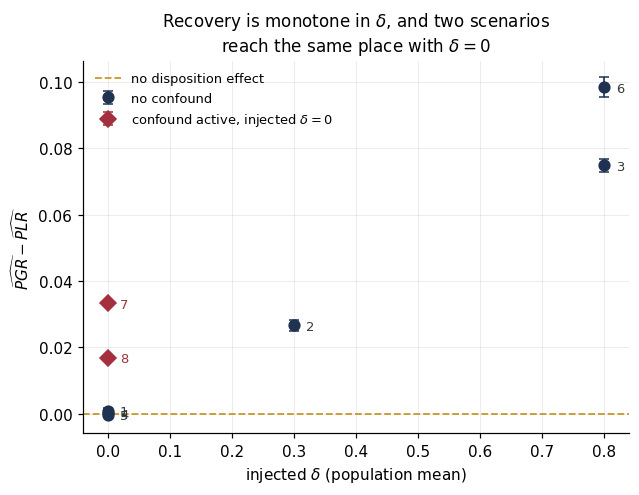

In [9]:
fx.monotonicity(table, f"{FIG}/monotonicity.png"); plt.show()

---

<a id="s5"></a>

## 5. The scenarios where something happened

### 5.1 Scenario 6: the difference is not a scale-free measure of the bias

Scenario 6 injects $\delta=0.8$ and $\kappa=0.8$ together. We predicted the measured
disposition would be **attenuated** relative to scenario 3, on the reasoning that higher churn
shortens holding periods and leaves positions closer to their purchase price. **That prediction
is wrong in the difference and right in the ratio**, and the two disagreeing is the point.
The difference rises from 0.0749 to 0.0985 while the ratio falls from 7.39 to 6.67.

The reason is that $\widehat{PGR}-\widehat{PLR}$ is not scale-free. Raising $\kappa$ raises
both realisation rates roughly proportionally — PGR goes from 0.0866 to 0.1158 and PLR from
0.0117 to 0.0174 — so a fixed multiplicative tilt produces a larger absolute gap simply because
both levels are larger. The ratio strips the level out and does fall, by the modest 10 % that
the shortened holding period justifies. A researcher reporting only the difference would
conclude that scenario 6's population is 32 % more loss-averse than scenario 3's, when the two
carry an identical injected $\delta$ and differ only in how often they trade. Odean reports
both statistics; this is why.

In [10]:
conv = convention_table(outputs)
conv.to_csv("results/conventions.csv")
conv

,Scenario,"per-lot, position","per-lot, share-weighted","average cost, position",silent days included,at basis (obs),se (account),se (position-day),understatement
#,,,,,,,,,
1,Null,0.00085,0.00085,0.00046,0.00005,0,0.00044,0.00045,0.97645
2,"Disposition only, low",0.02663,0.02663,0.02425,0.00239,0,0.00076,0.00042,1.81868
3,"Disposition only, high",0.07487,0.07487,0.06909,0.00638,0,0.00102,0.00044,2.31986
4,"Turnover only, low",0.00010,0.00010,-0.00016,-0.00009,0,0.00031,0.00030,1.00837
5,"Turnover only, high",-0.00029,-0.00029,-0.00027,-0.00016,0,0.00023,0.00024,0.96891
6,Both active,0.09846,0.09846,0.08966,0.02611,0,0.00148,0.00032,4.62760
7,Rebalancing confound,0.03338,0.00754,0.03326,0.00361,0,0.00048,0.00040,1.19089
8,Mean-reversion confound,0.01686,0.01686,0.01684,0.00138,0,0.00044,0.00043,1.04194


### 5.2 Scenario 7: rebalancing, and the convention that gives it away

Scenario 7 injects nothing at all. Accounts hold a target of equal weights and, once a month,
trim any position whose weight has drifted more than 25 % above target, redistributing the
proceeds to the positions that are below it. There is no reference point anywhere in the rule
and no parameter to recover. The estimator nevertheless returns
$\widehat{PGR}-\widehat{PLR} = 0.0334$ with a $t$ of 70, and a ratio of 1.83 — squarely inside
the range Odean reports for real brokerage accounts, and larger than the 1.74 that scenario 2
produces from a genuine injected $\delta$ of 0.3. Across eight redrawn panels it is
$0.0320\pm0.0027$, so it is not a fluke of one market. **A mechanical portfolio rule with no
behavioural content is indistinguishable from moderate loss aversion on the headline statistic.**

The mechanism is arithmetic rather than psychological. A position that rises gains weight and
breaches the band; a position that falls loses weight and is topped up. The rule sells winners
and buys losers because that is what equal-weighting means, and the disposition estimator has
no way to know that the seller was following a weight target rather than a reference point.

What does give it away is the partial-sale convention. Rebalancing trims: the mean fraction of
a position sold when a sale occurs is 0.712 in scenario 7 and exactly 1.000 in all seven other
scenarios. Counting realisations share-weighted rather than at position level therefore
collapses scenario 7's estimate from 0.0334 to 0.0075, a factor of 4.4, while leaving every
other scenario unchanged to five decimal places. That is a usable test on real data: if a
measured disposition effect largely disappears when partial sales are weighted by size, the
selling is rebalancing.

### 5.3 Scenario 8: a belief in reversal, wearing the same clothes

Scenario 8 also injects nothing. Agents believe past winners revert, so the sell hazard is
scaled by $1 + 0.6 z_{j,t}$ where $z$ is the security's cross-sectionally standardised
trailing 20-day return. The rule never looks at the purchase price. Because trailing return
and gain-versus-basis are correlated, the estimator returns 0.0169 with a $t$ of 38 and a ratio
of 1.41.

This one is harder to unmask than rebalancing, because the sales are whole positions and the
share-weighted convention does not move it at all (0.0169 under both). The tell has to come
from outside the purchase price.

In [11]:
disc = discrimination_table(outputs)
# The ratio is only meaningful where a disposition effect was measured at all;
# dividing a momentum tilt of 0.002 by a difference of 0.0001 is noise over noise.
disc["z tilt per unit of measured disposition"] = np.where(
    disc["PGR-PLR"] > 0.01, disc["z tilt"] / disc["PGR-PLR"], np.nan)
disc.to_csv("results/discrimination.csv")
disc

,Scenario,PGR-PLR,mean fraction sold,share-weighted PGR-PLR,"momentum z, sold","momentum z, held",z tilt,z tilt per unit of measured disposition
#,,,,,,,,
1,Null,0.00085,1.00000,0.00085,0.00171,-0.00041,0.00211,NaN
2,"Disposition only, low",0.02663,1.00000,0.02663,0.08520,-0.00403,0.08923,3.35091
3,"Disposition only, high",0.07487,1.00000,0.07487,0.25872,-0.00795,0.26666,3.56149
4,"Turnover only, low",0.00010,1.00000,0.00010,0.00236,0.00001,0.00235,NaN
5,"Turnover only, high",-0.00029,1.00000,-0.00029,0.00005,-0.00017,0.00022,NaN
6,Both active,0.09846,1.00000,0.09846,0.33696,-0.05072,0.38768,3.93752
7,Rebalancing confound,0.03338,0.71225,0.00754,0.57087,-0.00391,0.57478,17.21846
8,Mean-reversion confound,0.01686,1.00000,0.01686,0.52299,-0.02379,0.54678,32.42273


The trailing-momentum tilt — the mean standardised past return of what was sold, minus that of
what was held on the same days — separates the mechanisms, but only in ratio to the disposition
measured alongside it. A reference-point rule does tilt momentum, because winners against basis
are usually winners against the recent past too: scenario 3 sells positions whose trailing
$z$ is 0.267 above what it holds. But per unit of measured disposition the confounds are far
more momentum-driven, at 32.4 for scenario 8 and 17.2 for scenario 7 against 3.6 for scenario 3
and 3.3 for scenario 2. An account whose sales are extremely momentum-selective yet only mildly
disposition-selective is not following a reference point.

---

<a id="s6"></a>

## 6. Diagnosing the turnover slope on gross returns

The assignment asks which of four causes is responsible for a negative slope of gross returns
on turnover. **We never observe one.** The gross slope is quiet in every scenario where
$\kappa$ carries the variation — $-0.0018$ with $t=-0.53$ in scenario 4 and $-0.0006$ with
$t=-0.16$ in scenario 5 — and it is strongly *positive* in scenarios 2, 3, 6 and 8. The
diagnosis therefore runs in two parts: why nothing negative appears, and what the positive
slope is.

**Why nothing negative appears.** Leakage is excluded by the placebo of section 4, with every
scenario inside $|t|\le2.2$ on de-duplicated, day-clustered purchases. The spread is excluded
by definition, since gross return is a shadow portfolio filled at the mid rather than an
after-the-fact subtraction from a price path that already contains the spread. Cash drag is
excluded by construction, because proceeds are redeployed on the day of sale. The fourth cause,
compounding path effects, is present but small here: in scenario 5 the correlation between
turnover and gross return is $-0.020$, because redeployment is instantaneous and into an
equally random security, so turnover changes little about the portfolio's geometric return.

Cash drag is worth switching on rather than merely asserting away, so we re-run scenario 5 with
settlement lags of one, three and five days.

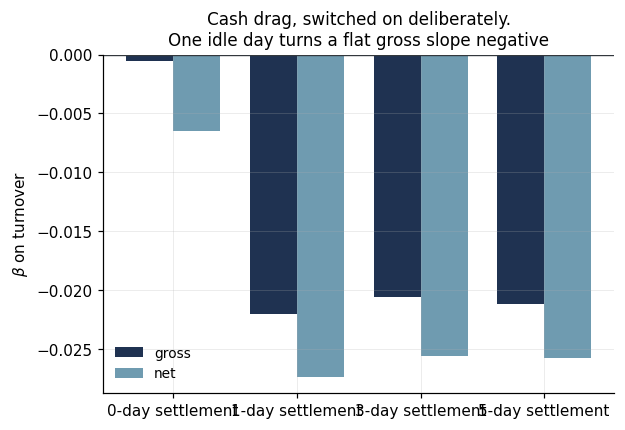

CPU times: total: 10.5 s
Wall time: 10.6 s


,beta_gross,t_gross,beta_net,t_net,mean gross return,mean turnover
settlement lag,,,,,,
0,-0.00056,-0.15817,-0.00647,-1.85902,0.18648,4.24579
1,-0.02202,-4.77485,-0.02738,-6.05722,0.16239,4.01367
3,-0.02060,-3.63205,-0.02555,-4.58990,0.14515,4.05721
5,-0.02118,-3.40419,-0.02577,-4.20994,0.13124,4.06105


In [12]:
%%time
rows = []
for lag in (0, 1, 3, 5):
    o = analyse(replace(SCENARIOS[4], engine=replace(EngineConfig(), settlement_lag=lag)),
                universe, n_boot=300)
    rows.append({"settlement lag": lag,
                 "beta_gross": o.over["ret_gross"]["beta"], "t_gross": o.over["ret_gross"]["t"],
                 "beta_net": o.over["ret_net"]["beta"], "t_net": o.over["ret_net"]["t"],
                 "mean gross return": o.df.ret_gross.mean(),
                 "mean turnover": o.df.turnover.mean()})
drag = pd.DataFrame(rows).set_index("settlement lag")
drag.to_csv("results/cash_drag.csv")
fx.cash_drag(drag.index.tolist(), drag["beta_gross"], drag["beta_net"], f"{FIG}/cash_drag.png")
plt.show()
drag

One idle day between sale and redeployment takes the gross slope from $-0.0006$ ($t=-0.16$) to
$-0.0220$ ($t=-4.77$), and drives the population's mean gross return from 18.6 % to 16.2 % and
on to 13.1 % at a five-day lag. The mechanism needs no informed trading whatever: a
high-turnover account simply spends more of its life out of a market that drifts upward. This
is the scenario in which a researcher would wrongly conclude that frequent traders pick bad
securities, and the tell is that the damage scales with time spent in cash rather than with
anything about the securities bought — which the placebo would confirm by staying silent.

**What the positive slope is.** In scenarios 2, 3, 6 and 8 the gross slope is positive and
significant, reaching $+0.151$ with $t=11.2$ in scenario 3. This is reverse causality, and the
simulator lets us prove it rather than argue it. The injected parameter $\delta$ is
uncorrelated with gross return at $-0.026$, so disposition strength does not cause performance.
Yet realised turnover correlates $+0.397$ with gross return in the same scenario. Turnover is
therefore partly an *outcome* of the return: an account whose securities happened to rise is
holding more winners, and a rule that sells winners at $(1+\delta)$ and holds losers at
$(1-\delta)$ converts that luck into trades. The regression reads the arrow backwards.

Where $\kappa$ provides genuine exogenous variation we can go further and replace the outcome
with its cause.

In [13]:
inst = pd.DataFrame({
    k: {"beta on realised turnover, gross": outputs[k].over["ret_gross"]["beta"],
        "beta on injected kappa, gross": outputs[k].over["ret_gross_kappa"]["beta"],
        "beta on injected kappa, net": outputs[k].over["ret_net_kappa"]["beta"],
        "corr(delta, ret_gross)": outputs[k].indep["corr_delta_retgross"],
        "corr(turnover, ret_gross)": outputs[k].indep["corr_turnover_retgross"]}
    for k in (2, 3, 5, 6, 7, 8)}).T
inst.index.name = "#"
inst

,"beta on realised turnover, gross","beta on injected kappa, gross","beta on injected kappa, net","corr(delta, ret_gross)","corr(turnover, ret_gross)"
#,,,,,
2,0.06266,NaN,NaN,-0.01608,0.15499
3,0.15070,NaN,NaN,-0.02618,0.39749
5,-0.00056,0.00857,-0.01534,NaN,-0.02036
6,0.02820,0.00813,-0.00903,0.01337,0.28036
7,0.01354,NaN,NaN,NaN,0.02215
8,0.06403,NaN,NaN,NaN,0.14230


In scenario 5, where the selling rule never looks at the purchase price, regressing on the
injected $\kappa$ instead of on realised turnover gives $+0.009$ on gross and $-0.015$ on net —
the Barber–Odean contrast in its clean form, with the cost effect intact and no endogeneity. In
scenario 6, where both parameters are active, the same substitution flips the gross coefficient
from $+0.028$ to $+0.008$ and turns the net coefficient from $+0.022$ to $-0.009$. The sign of
the net slope, which is the entire behavioural claim, reverses depending on whether the
right-hand side holds an outcome or a cause. In scenarios 2, 3, 7 and 8 no such substitution is
available because $\kappa$ is degenerate, which is precisely the situation a researcher with
real data is always in.

---

<a id="s7"></a>

## 7. Independence of the injected parameters

In [14]:
indep = independence_table(outputs)
indep.to_csv("results/independence.csv")
indep

,Scenario,corr_delta_kappa,se_corr_null,corr_delta_turnover,corr_kappa_turnover,corr_delta_retgross,corr_turnover_retgross
#,,,,,,,
1,Null,NaN,0.03167,NaN,NaN,NaN,-0.01215
2,"Disposition only, low",NaN,0.03167,0.13623,NaN,-0.01608,0.15499
3,"Disposition only, high",NaN,0.03167,-0.11245,NaN,-0.02618,0.39749
4,"Turnover only, low",NaN,0.03167,NaN,0.93889,NaN,-0.02436
5,"Turnover only, high",NaN,0.03167,NaN,0.85916,NaN,-0.02036
6,Both active,-0.04048,0.03167,-0.61651,0.58819,0.01337,0.28036
7,Rebalancing confound,NaN,0.03167,NaN,NaN,NaN,0.02215
8,Mean-reversion confound,NaN,0.03167,NaN,NaN,NaN,0.14230


In [15]:
%%time
rows = []
for rho in (0.0, 0.7, -0.7):
    o = analyse(replace(SCENARIOS[5], copula_rho=rho), universe, n_boot=300)
    rows.append({"copula rho": rho,
                 "realised corr(delta,kappa)": o.indep["corr_delta_kappa"],
                 "corr(delta,turnover)": o.indep["corr_delta_turnover"],
                 "corr(kappa,turnover)": o.indep["corr_kappa_turnover"],
                 "beta_gross": o.over["ret_gross"]["beta"],
                 "beta_net": o.over["ret_net"]["beta"],
                 "PGR-PLR": o.disp["diff"]})
copula = pd.DataFrame(rows).set_index("copula rho")
copula.to_csv("results/copula.csv")
copula

CPU times: total: 7.7 s
Wall time: 7.75 s


,"realised corr(delta,kappa)","corr(delta,turnover)","corr(kappa,turnover)",beta_gross,beta_net,PGR-PLR
copula rho,,,,,,
0.00000,-0.04048,-0.61651,0.58819,0.02820,0.02180,0.09846
0.70000,0.67697,-0.25671,0.27858,0.04517,0.03836,0.10401
-0.70000,-0.60934,-0.82034,0.77518,0.02196,0.01567,0.10036


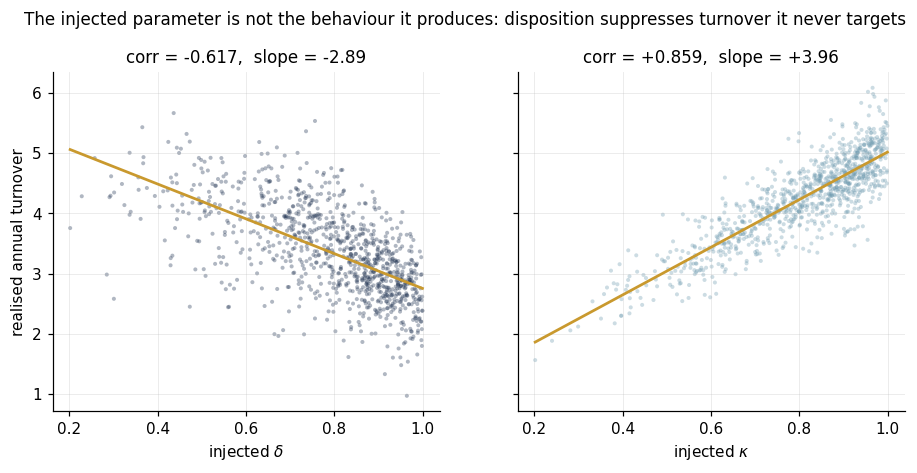

In [16]:
fx.turnover_vs_parameters(outputs[6].df, outputs[5].df, f"{FIG}/turnover_params.png"); plt.show()

**(1) The draws are independent.** $\delta_i$ and $\kappa_i$ come from separate generator
streams spawned off one master seed, so neither draw can shift the other.

**(2) The realised correlation.** Scenario 6 is the only scenario in which both parameters
carry dispersion, and there $\mathrm{corr}(\delta_i,\kappa_i) = -0.040$ against a null standard
error of $1/\sqrt{N-3} = 0.032$, a $t$ of $-1.28$. Everywhere else one of the two is degenerate
and the correlation is undefined rather than zero, which the table reports as a missing value.

**(3) The correlation between $\delta_i$ and realised turnover is not zero, and its sign
changes.** It is $+0.136$ in scenario 2, $-0.112$ in scenario 3 and $-0.617$ in scenario 6. The
injected parameter and the behaviour it produces are different objects, and the map between
them runs through the composition of the portfolio. Write the account's average hazard as
$h_0\bigl[(1+\delta)p_g + (1-\delta)p_l\bigr] = h_0\bigl[1+\delta(p_g-p_l)\bigr]$, where $p_g$
is the share of positions currently showing a gain. Two forces act in opposite directions. For
a given composition, raising $\delta$ raises the average hazard, because a drifting market
leaves more gains than losses and the $(1+\delta)$ arm applies to the larger pool — this is what
produces the positive correlation at $\delta=0.3$. But composition is itself endogenous to
$\delta$: an account that holds losers at $(1-\delta)$ accumulates them, $p_g$ falls, and the
tilt has a smaller pool to act on. At $\delta=0.8$ the second force dominates and the
correlation turns negative, strongly so when higher churn in scenario 6 lets the composition
effect express itself faster. Turnover is thus a *fixed point* of the mechanism rather than a
monotone function of the parameter, and no researcher measuring turnover is measuring $\kappa$.

**(4) What correlated parameters would do.** Coupling the two draws through a Gaussian copula
leaves the disposition estimate almost untouched, at 0.0985, 0.1040 and 0.1004 for
$\rho = 0,\,+0.7,\,-0.7$, and moves the overconfidence slope by more than half its value: the
gross coefficient runs $+0.028$, $+0.045$, $+0.022$ and the net coefficient $+0.022$, $+0.038$,
$+0.016$. The coefficient that is supposed to price trading moves by 60 % because of a
parameter that has nothing to do with costs. The reason is visible in the same table: a
positive $\rho$ partly cancels the composition effect described above, taking
$\mathrm{corr}(\delta,\text{turnover})$ from $-0.617$ to $-0.257$, so accounts with strong
disposition no longer trade distinctively little and the endogenous part of turnover is
reweighted. With the parameters correlated by construction, $\beta$ is a blend of the cost of
trading and the disposition mechanism's effect on trade frequency, and is not interpretable as
either.

---

<a id="s8"></a>

## 8. Standard errors and clustering

Positions inside an account share the account's $\delta$, its holding-period distribution and
its securities. Treating position-days as independent is therefore wrong, and the simulator
prices exactly how wrong.

In [17]:
se = conv[["Scenario", "se (account)", "se (position-day)", "understatement"]].copy()
se["t if clustered"] = table["PGR-PLR"] / conv["se (account)"]
se["t if not clustered"] = table["PGR-PLR"] / conv["se (position-day)"]
se

,Scenario,se (account),se (position-day),understatement,t if clustered,t if not clustered
#,,,,,,
1,Null,0.00044,0.00045,0.97645,1.95000,1.90409
2,"Disposition only, low",0.00076,0.00042,1.81868,35.08984,63.81729
3,"Disposition only, high",0.00102,0.00044,2.31986,73.35749,170.17878
4,"Turnover only, low",0.00031,0.00030,1.00837,0.33379,0.33659
5,"Turnover only, high",0.00023,0.00024,0.96891,-1.24497,-1.20626
6,Both active,0.00148,0.00032,4.62760,66.50418,307.75444
7,Rebalancing confound,0.00048,0.00040,1.19089,70.24093,83.64892
8,Mean-reversion confound,0.00044,0.00043,1.04194,38.06657,39.66293


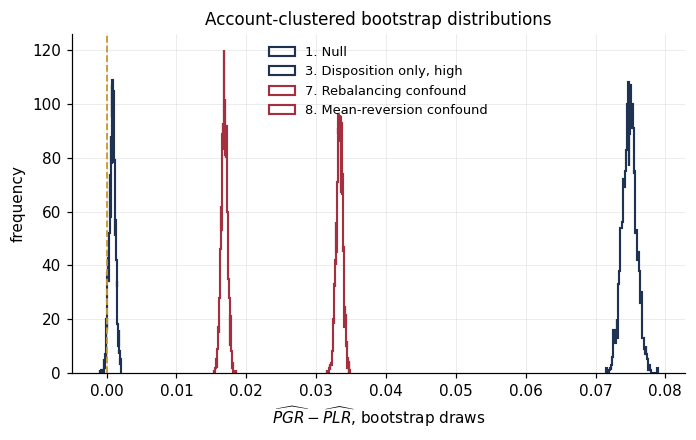

scenario 1: diff 95% CI [-0.00000, +0.00170]   ratio 95% CI [1.000, 1.034]
scenario 3: diff 95% CI [+0.07283, +0.07688]   ratio 95% CI [6.959, 7.842]
scenario 6: diff 95% CI [+0.09560, +0.10149]   ratio 95% CI [6.330, 7.037]
scenario 7: diff 95% CI [+0.03243, +0.03430]   ratio 95% CI [1.803, 1.858]
scenario 8: diff 95% CI [+0.01600, +0.01776]   ratio 95% CI [1.389, 1.440]


In [18]:
draws = {k: (f"{k}. {outputs[k].cfg.name}", outputs[k].boot["draws_diff"], k in (7, 8))
         for k in (1, 3, 7, 8)}
fx.bootstrap_density(draws, f"{FIG}/bootstrap.png"); plt.show()
for k in (1, 3, 6, 7, 8):
    lo, hi = outputs[k].boot["ci_diff"]
    rlo, rhi = outputs[k].boot["ci_ratio"]
    print(f"scenario {k}: diff 95% CI [{lo:+.5f}, {hi:+.5f}]   ratio 95% CI [{rlo:.3f}, {rhi:.3f}]")

The account bootstrap gives standard errors between 1.0 and 4.6 times the naive position-day
bootstrap, and the multiple tracks how concentrated the effect is within accounts: it is 1.00
in the null and in the turnover-only scenarios, where realisations really are close to
independent coin flips, 2.32 in scenario 3 and 4.63 in scenario 6, where each account's
$\delta$ makes all of its position-days move together. In scenario 6 that factor takes the
$t$-statistic from 66 to 308 — both reject, so nothing turns on it here, but the same factor
applied to a genuinely marginal effect manufactures significance out of nothing.

Section 4 adds the caveat that matters more. Clustering by account handles dependence *within*
an account and does nothing about the dependence induced by a single shared price path across
accounts, which is why the null's within-panel $t$ of 1.95 coexists with a mean effect of
0.00022 across redrawn panels. In real data the panel cannot be redrawn, so the honest reading
is that account-clustered standard errors are a lower bound on the uncertainty and a disposition
ratio inside roughly $1.00\pm0.03$ should not be reported as a finding at all.

For the overconfidence regression the unit of observation is the account itself, so there is no
cluster structure left to correct; HC1 handles the heteroskedasticity that account size
introduces.

---

<a id="s9"></a>

## 9. What the estimators cannot distinguish

The eight scenarios produce three pairs that the headline statistics cannot tell apart, and
each has a different remedy.

**A reference point cannot be told from a weight target.** Scenario 2 injects $\delta=0.3$ and
returns a ratio of 1.74; scenario 7 injects nothing, rebalances monthly, and returns 1.83. Both
sit inside the range reported for real brokerage data. Separating them needs the *size* of each
sale relative to the position, which brokerage extracts do carry: rebalancing trims, with a mean
sold fraction of 0.712 against 1.000 for a reference-point rule, and weighting realisations by
share collapses the rebalancing estimate by a factor of 4.4 while leaving the genuine effect
untouched. Holdings-level weights and, better, any record of a stated target allocation would
settle it outright.

**A reference point cannot be told from a belief about the price path.** Scenario 8's agents
never observe their purchase price, yet return a ratio of 1.41, because trailing return and
gain-versus-basis are correlated. Partial-sale weighting does not help, since the sales are
whole. What separates them is the trailing return of the security, which is observable: per unit
of measured disposition the momentum tilt is 32.4 in scenario 8 against 3.6 in scenario 3. The
decisive test is a joint model of the sale decision on both the gain indicator and the trailing
return, which is how Grinblatt and Han separate the two channels; if the gain indicator loses
its explanatory power once momentum is included, the reference point was never doing the work.
Neither PGR nor PLR can perform that test, because both compress the decision into a single
binary classification against one reference price.

**A cost of trading cannot be told from an effect of performance on trading.** Wherever the
selling rule conditions on the purchase price, turnover is partly an outcome of the return, and
the regression of return on turnover reads the arrow backwards: scenario 3's gross slope is
$+0.151$ even though the injected $\delta$ correlates $-0.026$ with gross return. Within the
simulator the fix is to regress on the injected $\kappa$, which flips scenario 6's net slope
from $+0.022$ to $-0.009$. Real data has no injected parameter, so it needs an instrument that
moves turnover without being moved by returns — a change in the commission schedule, a broker
platform migration, a tax rule change — or a panel long enough for account fixed effects with
lagged turnover. The cross-sectional regression on its own cannot do it, and this is the
limitation that most directly qualifies Barber and Odean's cross-sectional result.

A fourth thing no statistic here can separate is the magnitude of a bias from the frequency of
acting on it. Scenario 6 has the same injected $\delta$ as scenario 3 and a 32 % larger measured
difference, purely because it trades more. Reporting the ratio alongside the difference is the
minimum defence; recovering the underlying hazard tilt would require modelling the holding
period explicitly, which is a duration model rather than a proportion.

---

<a id="s10"></a>

## 10. Conclusions

The simulator recovers what it is given. The null returns a disposition difference of 0.00085
against a true value of zero, the recovered difference rises monotonically through 0.0266 and
0.0749 as $\delta$ goes from 0.3 to 0.8, each estimator stays silent when only the other's
parameter is active, and the turnover slope on net returns comes back at $-0.0078$ and
$-0.0065$ against a round-trip cost schedule of $-0.005$ written into the code. That last
number is the clearest statement of what the overconfidence regression actually measures: not a
psychological parameter, but the commission and spread the account paid.

The failures are more instructive than the recoveries. Two scenarios with no injected bias at
all return disposition ratios of 1.83 and 1.41, both inside the range reported for real
brokerage accounts and one of them larger than what a genuine $\delta$ of 0.3 produces. A
mechanical rebalancing rule and a belief in mean reversion are, on the headline statistic,
indistinguishable from loss aversion — and since the estimator is correct in the sense that it
computes exactly what it claims to compute, no amount of care in implementing it would have
revealed the problem. Only the ground truth does.

Three methodological consequences follow, and they are the ones we would carry to real data.
First, the difference $\widehat{PGR}-\widehat{PLR}$ is not a scale-free measure of a bias,
since scenario 6 posts a 32 % larger difference than scenario 3 on an identical injected
$\delta$ purely by trading more; the ratio must be reported alongside it, and neither is the
parameter. Second, clustering has to be argued rather than chosen: the account bootstrap
inflates standard errors by up to 4.6 times relative to the naive position-day version, and yet
is still a lower bound, because within a single price panel the null's $t$ reached 1.95 while
the effect across eight redrawn panels was 0.00022. Third, wherever a selling rule conditions on
the purchase price, turnover is an outcome and not a regressor, and the sign of the behavioural
claim depends on which of the two is on the right-hand side.

The exercise also produced one error worth naming, since the assignment asks for the diagnosis
rather than a clean result. Our first price specification gave each security a CAPM-like drift,
which makes expected log returns vary by three percentage points a year across the
cross-section and correlate $-0.90$ with idiosyncratic volatility; a rebalancing rule that buys
laggards then acquires a drift differential it had no information about, which is
observationally identical to leakage. Imposing a common expected log return removed it at the
source. The leakage placebo that caught it had to be fixed too, because counting the same
purchase once per account produced $t=-7.5$ on a panel with no predictability in it — the same
pseudo-replication failure the clustering discussion is about, appearing in the diagnostic
rather than in the estimator.

What we would want from real data, in order, is the size of each sale relative to the position,
the trailing return of the security alongside its purchase price, and an instrument for
turnover. The first separates rebalancing from a reference point, the second separates a belief
about prices from a reference point, and the third is the only thing that makes the
overconfidence coefficient mean what it is usually taken to mean.

---

<a id="s11"></a>

## 11. References

1. Barber, B. M., & Odean, T. (2000). Trading Is Hazardous to Your Wealth: The Common Stock Investment Performance of Individual Investors. *The Journal of Finance*, 55(2), 773–806.
2. Barberis, N., & Xiong, W. (2009). What Drives the Disposition Effect? An Analysis of a Long-Standing Preference-Based Explanation. *The Journal of Finance*, 64(2), 751–784.
3. Grinblatt, M., & Han, B. (2005). Prospect Theory, Mental Accounting, and Momentum. *Journal of Financial Economics*, 78(2), 311–339.
4. Odean, T. (1998). Are Investors Reluctant to Realize Their Losses? *The Journal of Finance*, 53(5), 1775–1798.
5. Odean, T. (1999). Do Investors Trade Too Much? *The American Economic Review*, 89(5), 1279–1298.

---

<a id="s12"></a>

## 12. Reproducibility

The simulator lives in `src/bfsim/` as six modules: `config.py` holds every parameter as a
frozen dataclass and the seed policy, `prices.py` the factor model and the leakage placebo,
`agents.py` the population draws, `engine.py` the daily loop, `estimators.py` the two
estimators and their bootstraps, and `scenarios.py` the eight configurations and the tables
below. All randomness descends from a single master seed through named, independently spawned
streams, so re-running this notebook from a clean kernel reproduces every number in it exactly.
Every table is written to `results/` and every figure to `results/figures/`.

In [19]:
import platform, statsmodels, matplotlib, nbformat
print(f"python      {platform.python_version()}")
for m in (np, pd, statsmodels, matplotlib):
    print(f"{m.__name__:<12}{m.__version__}")
print(f"master seed {MASTER_SEED}")
print(f"scenarios   {len(SCENARIOS)}   traders/scenario {SCENARIOS[0].n_traders}   "
      f"securities {price_cfg.n_securities}   days {price_cfg.n_days}")

python      3.12.5
numpy       2.1.3
pandas      2.2.3
statsmodels 0.14.5
matplotlib  3.9.2
master seed 20260913
scenarios   8   traders/scenario 1000   securities 60   days 750
